### [Enhanced LLM-Augmented Algorithmic Trading](https://medium.com/@adalegend/enhanced-llm-augmented-algorithmic-trading-practical-sentiment-analysis-for-optimized-strategies-9684d4e033b8)

> A 5 years AAPL and MSFT case study of a real scenario.

In [1]:
!pip install -U -q yfinance

In [3]:
import pandas as pd
import yfinance as yf  # For stock data; install if needed
from transformers import pipeline  # Hugging Face library; requires PyTorch for models
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np  # For any numerical operations
import requests
import csv
import io
import sys

# Increase CSV field size limit to handle large fields
csv.field_size_limit(10**7)  # Set to 10 million characters; adjust if needed

# Step 1: Data Collection and Preprocessing
# Fetch historical stock data (e.g., AAPL)
stock_data = yf.download('AAPL', start='2020-01-01', end='2025-08-15')
# Flatten multi-level columns if present
stock_data.columns = stock_data.columns.droplevel(1) if isinstance(stock_data.columns, pd.MultiIndex) else stock_data.columns
stock_data['Returns'] = stock_data['Close'].pct_change()

# Fetch real news data from FNSPID dataset CSV (public, no registration; stream and filter for AAPL to avoid memory issues)
news_url = 'https://huggingface.co/datasets/Zihan1004/FNSPID/resolve/main/Stock_news/nasdaq_exteral_data.csv'
response = requests.get(news_url, stream=True)
response.raise_for_status()  # Ensure successful response

# Stream and filter CSV for AAPL rows
reader = csv.reader(line.decode('utf-8') for line in response.iter_lines() if line)
header = next(reader)
stock_idx = header.index('Stock_symbol')
date_idx = header.index('Date')
title_idx = header.index('Article_title')

aapl_rows = []
for row in reader:
    if row and len(row) > max(stock_idx, date_idx, title_idx) and row[stock_idx] == 'AAPL':
        aapl_rows.append(row)

news_data = pd.DataFrame(aapl_rows, columns=header)
news_data['Date'] = pd.to_datetime(news_data['Date'])  # Ensure datetime format
news_data = news_data[(news_data['Date'] >= '2020-01-01') & (news_data['Date'] <= '2025-08-15')]  # Filter date range
news_data['Date'] = news_data['Date'].dt.date  # Floor to daily for aggregation

# Initialize LLM sentiment pipeline (requires PyTorch or TensorFlow)
sentiment_pipeline = pipeline('sentiment-analysis', model='distilbert-base-uncased-finetuned-sst-2-english')

# Compute sentiment scores on article titles
def get_sentiment(text):
    if pd.isna(text):
        return 0  # Neutral for missing text
    result = sentiment_pipeline(text)[0]
    return result['score'] if result['label'] == 'POSITIVE' else -result['score']

news_data['Sentiment'] = news_data['Article_title'].apply(get_sentiment)  # Use 'Article_title'; alternatively 'Article' for full text

# Aggregate sentiment by date (mean)
sentiment_data = news_data.groupby('Date')['Sentiment'].mean().reset_index()
sentiment_data['Date'] = pd.to_datetime(sentiment_data['Date'])  # Ensure datetime

# Reset index to column for safe merge
stock_data = stock_data.reset_index()

print("Stock data:")
print(stock_data.head())
print("News data:")
print(news_data.head())
print("Sentiment data:")
print(sentiment_data.head())

/tmp/ipython-input-3491632056.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download('AAPL', start='2020-01-01', end='2025-08-15')
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cpu


Stock data:
Price       Date      Close       High        Low       Open     Volume  \
0     2020-01-02  72.538506  72.598884  71.292296  71.545882  135480400   
1     2020-01-03  71.833282  72.594048  71.608677  71.765659  146322800   
2     2020-01-06  72.405685  72.444328  70.703020  70.954195  118387200   
3     2020-01-07  72.065163  72.671356  71.845385  72.415353  108872000   
4     2020-01-08  73.224403  73.526295  71.768079  71.768079  132079200   

Price   Returns  
0           NaN  
1     -0.009722  
2      0.007968  
3     -0.004703  
4      0.016086  
News data:
  Unnamed: 0        Date                                      Article_title  \
0    12025.0  2023-12-16  My 6 Largest Portfolio Holdings Heading Into 2...   
1    12026.0  2023-12-16  Brokers Suggest Investing in Apple (AAPL): Rea...   
2    12027.0  2023-12-16                      Company News for Dec 19, 2023   
3    12028.0  2023-12-16  NVIDIA (NVDA) Up 243% YTD: Will It Carry Momen...   
4    12029.0  2023-12-1

In [4]:
# Step 2: Feature Engineering and Modeling
# Merge datasets on 'Date' column
merged_data = pd.merge(stock_data, sentiment_data, on='Date', how='left')  # Left join to keep all stock dates
merged_data['Sentiment'] = merged_data['Sentiment'].fillna(0)  # Fill missing with neutral
merged_data = merged_data.set_index('Date')  # Restore index
merged_data['Label'] = (merged_data['Returns'] > 0).astype(int)  # 1 for positive return

# Features: Sentiment and simple MA
merged_data['MA_5'] = merged_data['Close'].rolling(5).mean()
features = merged_data[['Sentiment', 'MA_5']].dropna()
labels = merged_data['Label'].loc[features.index]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

print("X Train:")
print(X_train.head())

print("X Test:")
print(X_test.head())

# Logistic Regression
model = LogisticRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f'Accuracy: {accuracy:.2f}')

X Train:
            Sentiment        MA_5
Date                             
2025-05-01   0.000000  210.774084
2022-04-26   0.000000  160.032834
2024-07-17   0.000000  229.904675
2020-03-18  -0.011867   61.390222
2020-08-19   0.000000  112.017207
X Test:
            Sentiment        MA_5
Date                             
2021-06-03   0.000000  121.752722
2023-06-14   0.068099  180.501868
2024-08-20   0.000000  223.935806
2020-10-12   0.000000  113.726277
2023-02-15  -0.303846  150.910977
Accuracy: 0.56


/tmp/ipython-input-1227427783.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f'Cumulative Return for MSFT: {cumulative_returns_aapl[-1]:.2f}')


Cumulative Return for MSFT: 1.83


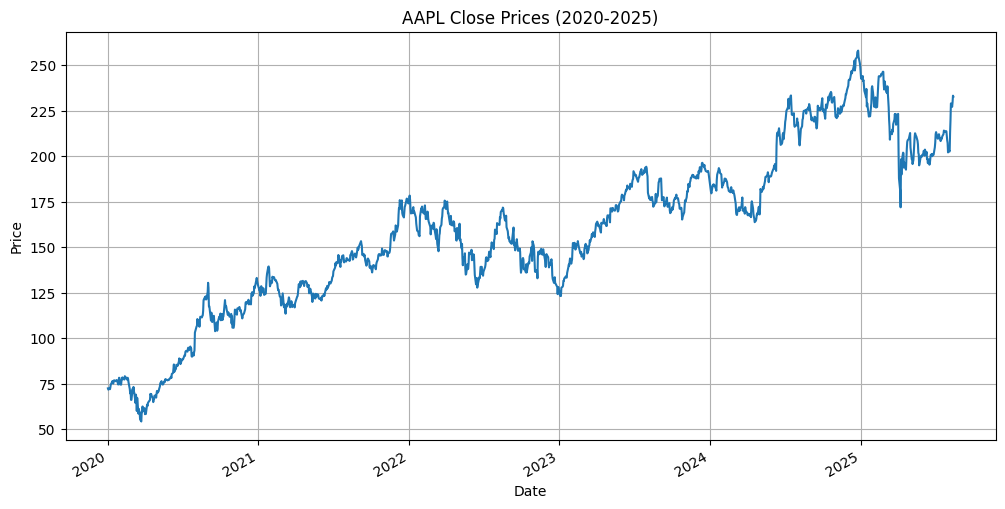

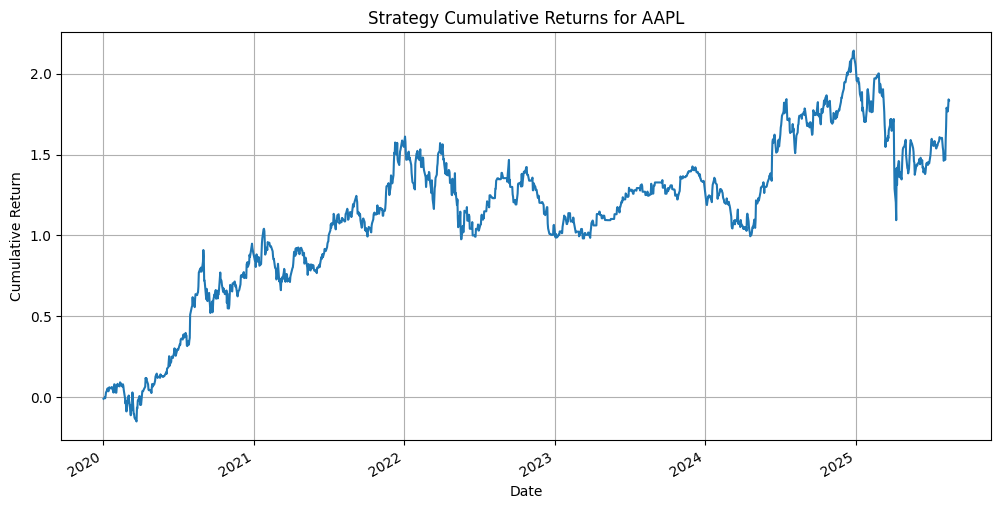

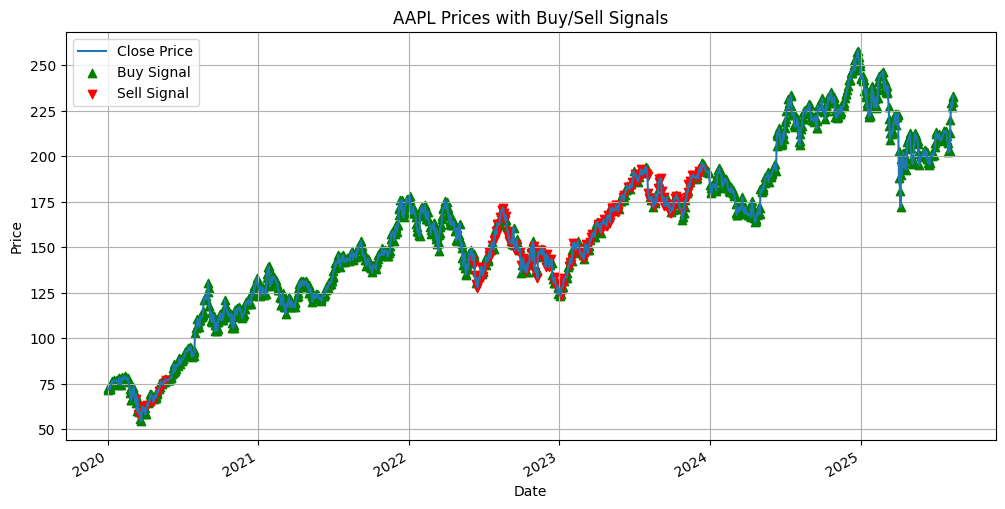

In [6]:
# Backtest strategy on MSFT using the model trained on AAPL
merged_data['Signal'] = model.predict(merged_data[['Sentiment', 'MA_5']].fillna(0))
merged_data['Strategy_Return'] = merged_data['Returns'] * merged_data['Signal'].shift(1)
cumulative_returns_aapl = (1 + merged_data['Strategy_Return'].dropna()).cumprod() - 1
print(f'Cumulative Return for MSFT: {cumulative_returns_aapl[-1]:.2f}')

# Step 4: Plot Charts for AAPL
# Plot AAPL Close Prices
plt.figure(figsize=(12, 6))
merged_data['Close'].plot()
plt.title('AAPL Close Prices (2020-2025)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()

# Plot Cumulative Strategy Returns
plt.figure(figsize=(12, 6))
cumulative_returns_aapl.plot()
plt.title('Strategy Cumulative Returns for AAPL')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.grid(True)
plt.show()

# Optional: Plot Buy/Sell Signals on Price Chart
plt.figure(figsize=(12, 6))
merged_data['Close'].plot(label='Close Price')
buy_signals = merged_data[merged_data['Signal'] == 1]
sell_signals = merged_data[merged_data['Signal'] == 0]
plt.scatter(buy_signals.index, buy_signals['Close'], marker='^', color='g', label='Buy Signal')
plt.scatter(sell_signals.index, sell_signals['Close'], marker='v', color='r', label='Sell Signal')
plt.title('AAPL Prices with Buy/Sell Signals')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipython-input-1369091340.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data_msft = yf.download('MSFT', start='2020-01-01', end='2025-08-15')
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1369091340.py:50: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f'Cumulative Return for MSFT: {cumulative_returns[-1]:.2f}')


Cumulative Return for MSFT: 1.01


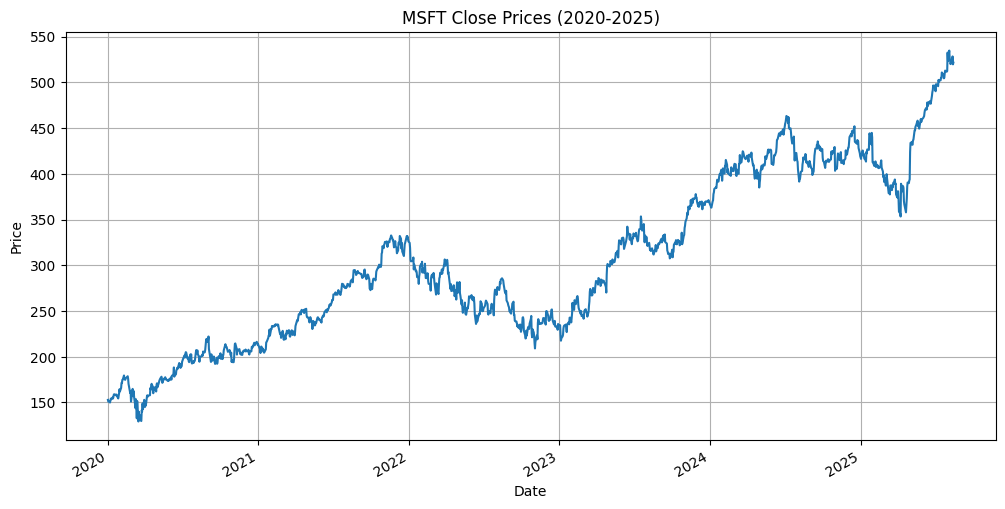

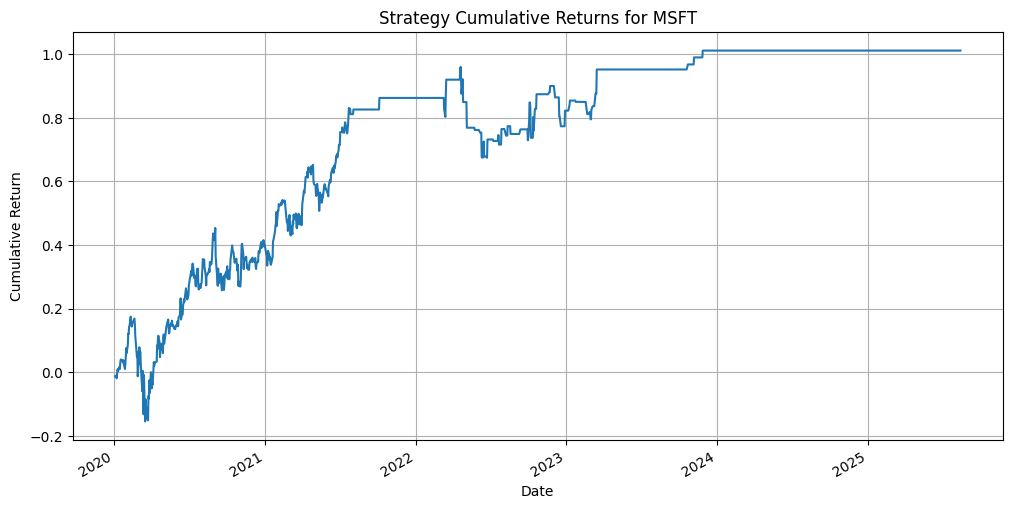

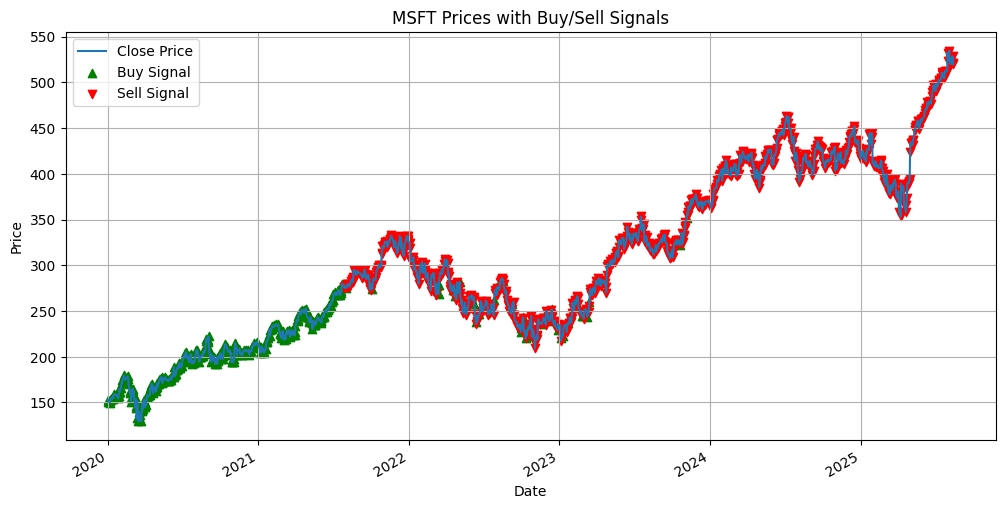

In [5]:
# Step 3: Trading Strategy Simulation (Independent Evaluation on MSFT)
# Fetch historical stock data for MSFT
stock_data_msft = yf.download('MSFT', start='2020-01-01', end='2025-08-15')
# Flatten multi-level columns if present
stock_data_msft.columns = stock_data_msft.columns.droplevel(1) if isinstance(stock_data_msft.columns, pd.MultiIndex) else stock_data_msft.columns
stock_data_msft['Returns'] = stock_data_msft['Close'].pct_change()

# Fetch real news data from FNSPID dataset CSV (stream and filter for MSFT)
response = requests.get(news_url, stream=True)
response.raise_for_status()

# Stream and filter CSV for MSFT rows
reader = csv.reader(line.decode('utf-8') for line in response.iter_lines() if line)
header = next(reader)
stock_idx = header.index('Stock_symbol')
date_idx = header.index('Date')
title_idx = header.index('Article_title')

msft_rows = []
for row in reader:
    if row and len(row) > max(stock_idx, date_idx, title_idx) and row[stock_idx] == 'MSFT':
        msft_rows.append(row)

news_data_msft = pd.DataFrame(msft_rows, columns=header)
news_data_msft['Date'] = pd.to_datetime(news_data_msft['Date'])  # Ensure datetime format
news_data_msft = news_data_msft[(news_data_msft['Date'] >= '2020-01-01') & (news_data_msft['Date'] <= '2025-08-15')]  # Filter date range
news_data_msft['Date'] = news_data_msft['Date'].dt.date  # Floor to daily for aggregation

news_data_msft['Sentiment'] = news_data_msft['Article_title'].apply(get_sentiment)

# Aggregate sentiment by date (mean)
sentiment_data_msft = news_data_msft.groupby('Date')['Sentiment'].mean().reset_index()
sentiment_data_msft['Date'] = pd.to_datetime(sentiment_data_msft['Date'])

# Reset index to column for safe merge
stock_data_msft = stock_data_msft.reset_index()

# Merge datasets on 'Date' column for MSFT
merged_data_msft = pd.merge(stock_data_msft, sentiment_data_msft, on='Date', how='left')
merged_data_msft['Sentiment'] = merged_data_msft['Sentiment'].fillna(0)
merged_data_msft = merged_data_msft.set_index('Date')

# Features for MSFT
merged_data_msft['MA_5'] = merged_data_msft['Close'].rolling(5).mean()

# Backtest strategy on MSFT using the model trained on AAPL
merged_data_msft['Signal'] = model.predict(merged_data_msft[['Sentiment', 'MA_5']].fillna(0))
merged_data_msft['Strategy_Return'] = merged_data_msft['Returns'] * merged_data_msft['Signal'].shift(1)
cumulative_returns = (1 + merged_data_msft['Strategy_Return'].dropna()).cumprod() - 1
print(f'Cumulative Return for MSFT: {cumulative_returns[-1]:.2f}')

# Step 4: Plot Charts for MSFT
# Plot MSFT Close Prices
plt.figure(figsize=(12, 6))
merged_data_msft['Close'].plot()
plt.title('MSFT Close Prices (2020-2025)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()

# Plot Cumulative Strategy Returns
plt.figure(figsize=(12, 6))
cumulative_returns.plot()
plt.title('Strategy Cumulative Returns for MSFT')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.grid(True)
plt.show()

# Optional: Plot Buy/Sell Signals on Price Chart
plt.figure(figsize=(12, 6))
merged_data_msft['Close'].plot(label='Close Price')
buy_signals = merged_data_msft[merged_data_msft['Signal'] == 1]
sell_signals = merged_data_msft[merged_data_msft['Signal'] == 0]
plt.scatter(buy_signals.index, buy_signals['Close'], marker='^', color='g', label='Buy Signal')
plt.scatter(sell_signals.index, sell_signals['Close'], marker='v', color='r', label='Sell Signal')
plt.title('MSFT Prices with Buy/Sell Signals')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()